In [49]:
# Ncessary import for graphs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx

In [50]:
# Read nodes and edges from CSV files

nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')



In [51]:
nodes_df.head()

,Id,Label
0,5097316,ROSE
1,5098095,JACK
2,5097875,CAL
3,5098619,MOLLY
4,5098545,SMITH


In [52]:
nodes_df.shape # We have 70 nodes.

(70, 2)

In [53]:
edges_df.head()

,Source,Target,Weight
0,5096932,5096969,1
1,5098606,5103789,1
2,5098606,5098095,1
3,5098606,5101061,1
4,5098606,5097941,1


In [54]:
edges_df['Weight'].describe()

count    299.000000
mean       1.481605
std        1.431488
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       19.000000
Name: Weight, dtype: float64

In [55]:
# Check whether each of the source and target in edges_df exists in nodes_df
missing_sources = set(edges_df['Source']) - set(nodes_df['Id'])
missing_targets = set(edges_df['Target']) - set(nodes_df['Id'])



Every element of the source and the target is member of the ID from the nodes_df

In [57]:
# Create a graph and add nodes from nodes_df, then add edges and their weights from edges_df
G = nx.Graph()
# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G.add_node(row['Id'], label=row['Label'], group=row['Label']) 
# Add edges with weights
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

# Print basic graph information
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


Number of nodes: 70
Number of edges: 299


In [58]:
# Print the edges with their weights
for u, v, data in G.edges(data=True):
    # Print the source, target, and weight of each edge in the format "Source -> Target (Weight)" and also print the labels of the source and target nodes
    # order by the weight of the edge in descending order
    print(f"{G.nodes[u]['label']} ({u}) -> {G.nodes[v]['label']} ({v}) (Weight: {data['weight']})")

    

ROSE (5097316) -> BODINE (5096948) (Weight: 4)
ROSE (5097316) -> BUELL (5097212) (Weight: 1)
ROSE (5097316) -> CAL (5097875) (Weight: 8)
ROSE (5097316) -> CNN REPORTER (5097296) (Weight: 1)
ROSE (5097316) -> COLONEL GRACIE (5099110) (Weight: 1)
ROSE (5097316) -> FABRIZIO (5098128) (Weight: 2)
ROSE (5097316) -> GENTLEMAN (5102317) (Weight: 1)
ROSE (5097316) -> GUGGENHEIM (5100327) (Weight: 1)
ROSE (5097316) -> HELGA (5099499) (Weight: 1)
ROSE (5097316) -> HUSBAND (5104295) (Weight: 1)
ROSE (5097316) -> HUTCHINSON (5102267) (Weight: 1)
ROSE (5097316) -> JOUGHIN (5105104) (Weight: 1)
ROSE (5097316) -> LIGHTOLLER (5101061) (Weight: 2)
ROSE (5097316) -> LIZZY (5097505) (Weight: 4)
ROSE (5097316) -> LOVEJOY (5097941) (Weight: 3)
ROSE (5097316) -> MAN (5097994) (Weight: 3)
ROSE (5097316) -> MARVIN (5099903) (Weight: 1)
ROSE (5097316) -> OLD ROSE (5098041) (Weight: 5)
ROSE (5097316) -> OPERATOR (5103330) (Weight: 1)
ROSE (5097316) -> ANDREWS (5098606) (Weight: 4)
ROSE (5097316) -> BROCK (50993

In [59]:
print(G.nodes(data=True))

[(5097316, {'label': 'ROSE', 'group': 'ROSE'}), (5098095, {'label': 'JACK', 'group': 'JACK'}), (5097875, {'label': 'CAL', 'group': 'CAL'}), (5098619, {'label': 'MOLLY', 'group': 'MOLLY'}), (5098545, {'label': 'SMITH', 'group': 'SMITH'}), (5101061, {'label': 'LIGHTOLLER', 'group': 'LIGHTOLLER'}), (5096969, {'label': 'LOVETT', 'group': 'LOVETT'}), (5097941, {'label': 'LOVEJOY', 'group': 'LOVEJOY'}), (5098606, {'label': 'ANDREWS', 'group': 'ANDREWS'}), (5097894, {'label': 'RUTH', 'group': 'RUTH'}), (5098041, {'label': 'OLD ROSE', 'group': 'OLD ROSE'}), (5096948, {'label': 'BODINE', 'group': 'BODINE'}), (5098128, {'label': 'FABRIZIO', 'group': 'FABRIZIO'}), (5098463, {'label': 'WOMAN', 'group': 'WOMAN'}), (5098583, {'label': 'ISMAY', 'group': 'ISMAY'}), (5101981, {'label': 'MURDOCH', 'group': 'MURDOCH'}), (5100134, {'label': 'STEWARD', 'group': 'STEWARD'}), (5097212, {'label': 'BUELL', 'group': 'BUELL'}), (5101285, {'label': 'FLEET', 'group': 'FLEET'}), (5101840, {'label': 'LEE', 'group': 

In [60]:
! pip install plotly

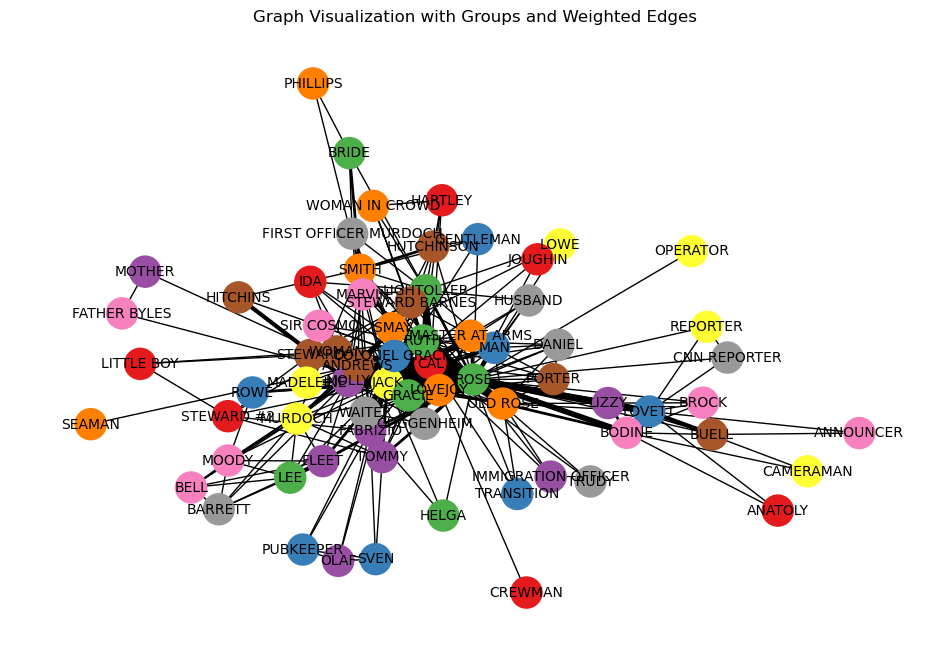

In [61]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

# Convert group names to numeric color ids
groups = list(set(nx.get_node_attributes(G, 'group').values()))
group_map = {group: i for i, group in enumerate(groups)}

node_colors = [group_map[G.nodes[node]['group']] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.Set1,
    node_size=500
)

# Edge widths
edge_weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights)

# Labels
labels = {node: G.nodes[node]['label'] for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title("Graph Visualization with Groups and Weighted Edges")
plt.axis('off')
plt.show()

**VALIDATION OF NETWORK**

In [63]:
"""
This script performs a comprehensive validation of the network
constructed from nodes.csv and edges.csv.

Checks performed:

1. Data loading
2. Schema validation
3. Missing node references
4. Duplicate edges
5. Self-loops
6. Edge weight validity
7. Graph construction
8. Graph structural properties
9. Connectivity analysis
10. Degree statistics
11. Isolated nodes
12. Basic sanity checks

"""

# ==========================================================
# 1. LOAD DATA
# ==========================================================

print("\n==============================")
print("1. LOADING DATA")
print("==============================")

nodes_df = pd.read_csv("nodes.csv")
edges_df = pd.read_csv("edges.csv")

print("Nodes shape:", nodes_df.shape)
print("Edges shape:", edges_df.shape)

print("\nSample nodes:")
print(nodes_df.head())

print("\nSample edges:")
print(edges_df.head())


# ==========================================================
# 2. CHECK SCHEMA
# ==========================================================

print("\n==============================")
print("2. VALIDATING SCHEMA")
print("==============================")

required_node_columns = {"Id", "Label"}
required_edge_columns = {"Source", "Target", "Weight"}

assert required_node_columns.issubset(nodes_df.columns), \
    "Node file missing required columns"

assert required_edge_columns.issubset(edges_df.columns), \
    "Edge file missing required columns"

print("✔ Node schema valid")
print("✔ Edge schema valid")


# ==========================================================
# 3. CHECK MISSING NODE REFERENCES
# ==========================================================

print("\n==============================")
print("3. CHECKING EDGE REFERENCES")
print("==============================")

node_ids = set(nodes_df["Id"])

missing_sources = set(edges_df["Source"]) - node_ids
missing_targets = set(edges_df["Target"]) - node_ids

print("Missing source nodes:", missing_sources)
print("Missing target nodes:", missing_targets)

if len(missing_sources) == 0 and len(missing_targets) == 0:
    print("✔ All edges reference valid nodes")
else:
    print("⚠ Invalid node references detected")


# ==========================================================
# 4. CHECK DUPLICATE EDGES
# ==========================================================

print("\n==============================")
print("4. CHECKING DUPLICATE EDGES")
print("==============================")

duplicate_edges = edges_df.duplicated(subset=["Source", "Target"]).sum()

print("Duplicate edges:", duplicate_edges)

if duplicate_edges == 0:
    print("✔ No duplicate edges")
else:
    print("⚠ Duplicate edges detected")


# ==========================================================
# 5. CHECK SELF LOOPS
# ==========================================================

print("\n==============================")
print("5. CHECKING SELF LOOPS")
print("==============================")

self_loops = edges_df[edges_df["Source"] == edges_df["Target"]]

print("Self-loop count:", len(self_loops))

if len(self_loops) == 0:
    print("✔ No self-loops detected")
else:
    print("⚠ Self-loops detected")


# ==========================================================
# 6. CHECK EDGE WEIGHTS
# ==========================================================

print("\n==============================")
print("6. CHECKING EDGE WEIGHTS")
print("==============================")

print(edges_df["Weight"].describe())

if edges_df["Weight"].isnull().sum() == 0:
    print("✔ No missing weights")
else:
    print("⚠ Missing weight values detected")


# ==========================================================
# 7. BUILD GRAPH
# ==========================================================

print("\n==============================")
print("7. BUILDING GRAPH")
print("==============================")

G = nx.Graph()

# Add nodes
for _, row in nodes_df.iterrows():
    G.add_node(row["Id"], label=row["Label"])

# Add edges
for _, row in edges_df.iterrows():
    G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

print("Graph successfully created")


# ==========================================================
# 8. BASIC GRAPH INFO
# ==========================================================

print("\n==============================")
print("8. BASIC GRAPH STATISTICS")
print("==============================")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

density = nx.density(G)
print("Graph density:", density)

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", avg_degree)


# ==========================================================
# 9. CONNECTIVITY
# ==========================================================

print("\n==============================")
print("9. CONNECTIVITY ANALYSIS")
print("==============================")

is_connected = nx.is_connected(G)

print("Is graph connected?", is_connected)

components = list(nx.connected_components(G))
print("Number of connected components:", len(components))

component_sizes = [len(c) for c in components]

print("Component sizes:", component_sizes)

largest_component = max(component_sizes)
print("Largest component size:", largest_component)


# ==========================================================
# 10. DEGREE DISTRIBUTION SUMMARY
# ==========================================================

print("\n==============================")
print("10. DEGREE STATISTICS")
print("==============================")

degrees = [d for n, d in G.degree()]

print("Minimum degree:", min(degrees))
print("Maximum degree:", max(degrees))
print("Average degree:", sum(degrees) / len(degrees))


# ==========================================================
# 11. ISOLATED NODES
# ==========================================================

print("\n==============================")
print("11. ISOLATED NODE CHECK")
print("==============================")

isolated_nodes = list(nx.isolates(G))

print("Number of isolated nodes:", len(isolated_nodes))

if len(isolated_nodes) > 0:
    print("Isolated node IDs:", isolated_nodes)
else:
    print("✔ No isolated nodes detected")


# ==========================================================
print("GRAPH VALIDATION COMPLETE")



1. LOADING DATA
Nodes shape: (70, 2)
Edges shape: (299, 3)

Sample nodes:
        Id  Label
0  5097316   ROSE
1  5098095   JACK
2  5097875    CAL
3  5098619  MOLLY
4  5098545  SMITH

Sample edges:
    Source   Target  Weight
0  5096932  5096969       1
1  5098606  5103789       1
2  5098606  5098095       1
3  5098606  5101061       1
4  5098606  5097941       1

2. VALIDATING SCHEMA
✔ Node schema valid
✔ Edge schema valid

3. CHECKING EDGE REFERENCES
Missing source nodes: set()
Missing target nodes: set()
✔ All edges reference valid nodes

4. CHECKING DUPLICATE EDGES
Duplicate edges: 0
✔ No duplicate edges

5. CHECKING SELF LOOPS
Self-loop count: 0
✔ No self-loops detected

6. CHECKING EDGE WEIGHTS
count    299.000000
mean       1.481605
std        1.431488
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       19.000000
Name: Weight, dtype: float64
✔ No missing weights

7. BUILDING GRAPH
Graph successfully created

8. BASIC GRAPH STATISTICS
Number 

## Degree Distribution

The first step in analyzing the network structure is examining the **degree distribution**.  
The degree of a node represents the number of connections it has with other nodes in the network.

Studying the degree distribution allows us to understand how connectivity is distributed among nodes. In particular, it helps determine whether the network is **homogeneous**, where most nodes have similar numbers of connections, or **heterogeneous**, where a few nodes act as highly connected hubs.

To investigate this property, we compute the degree of every node in the graph and visualize the distribution using a histogram. This plot shows how many nodes have a given number of connections.

Networks with a heavy-tailed distribution often indicate the presence of hubs, which are nodes that play an important role in maintaining connectivity within the network.


Building graph...
Graph built successfully.
Nodes: 70
Edges: 299

Degree Statistics
-----------------
Minimum degree: 1
Maximum degree: 46
Average degree: 8.542857142857143


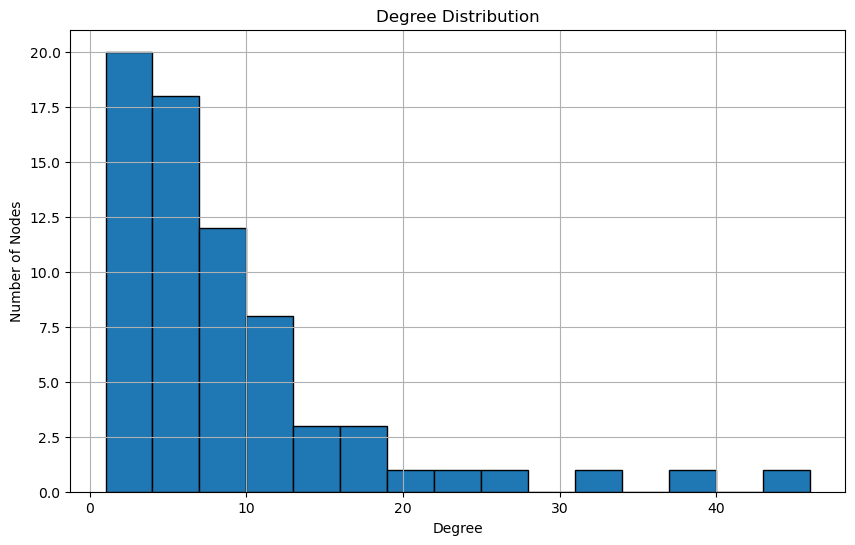

In [65]:
"""

This module computes and visualizes the degree distribution
of a network built from nodes.csv and edges.csv.

Why degree distribution matters:
- Reveals heterogeneity in the network
- Identifies presence of hubs
- Helps compare real networks to random graph models

Outputs:
1. Histogram of node degrees
2. Summary statistics
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# GRAPH CONSTRUCTION
# ---------------------------------------------------------

def build_graph(nodes_path: str, edges_path: str) -> nx.Graph:
    """
    Build a NetworkX graph from CSV files.

    Parameters
    ----------
    nodes_path : str
        Path to nodes CSV file
    edges_path : str
        Path to edges CSV file

    Returns
    -------
    G : networkx.Graph
        Constructed graph with node labels and weighted edges
    """

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    G = nx.Graph()

    # Add nodes
    for _, row in nodes_df.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    # Add edges
    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

    return G


# ---------------------------------------------------------
# DEGREE COMPUTATION
# ---------------------------------------------------------

def compute_degrees(G: nx.Graph):
    """
    Extract node degree values.

    Parameters
    ----------
    G : networkx.Graph
        Network graph

    Returns
    -------
    list
        List of degree values for all nodes
    """

    degrees = [degree for _, degree in G.degree()]
    return degrees


# ---------------------------------------------------------
# DEGREE STATISTICS
# ---------------------------------------------------------

def print_degree_statistics(degrees):
    """
    Print useful degree statistics.

    Parameters
    ----------
    degrees : list
        List of node degree values
    """

    print("\nDegree Statistics")
    print("-----------------")
    print("Minimum degree:", min(degrees))
    print("Maximum degree:", max(degrees))
    print("Average degree:", sum(degrees) / len(degrees))


# ---------------------------------------------------------
# DEGREE DISTRIBUTION PLOT
# ---------------------------------------------------------

def plot_degree_distribution(degrees):
    """
    Plot histogram of node degrees.

    Parameters
    ----------
    degrees : list
        Degree values of all nodes
    """

    plt.figure(figsize=(10, 6))

    plt.hist(degrees, bins=15, edgecolor="black")

    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Number of Nodes")

    plt.grid(True)

    plt.show()


# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def main():
    """
    Main workflow for degree distribution visualization.
    """

    print("\nBuilding graph...")

    G = build_graph("nodes.csv", "edges.csv")

    print("Graph built successfully.")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    degrees = compute_degrees(G)

    print_degree_statistics(degrees)

    plot_degree_distribution(degrees)


# ---------------------------------------------------------

if __name__ == "__main__":
    main()

**Degree-Scaled Network Visualization**
-----------------------------------

## Network Visualization with Degree-Based Node Size

After analyzing the degree distribution, we visualize the network structure by scaling node size according to node degree.

In this visualization, each node represents a character in the network, while edges represent interactions between characters. The size of each node is proportional to its degree, meaning that nodes with more connections appear larger.

This representation allows us to visually identify **hub nodes**, which correspond to characters with a large number of interactions. These nodes often represent central figures in the narrative structure and play a significant role in connecting different parts of the network.

By visually emphasizing highly connected nodes, this visualization provides an intuitive understanding of the network's structure and highlights the most influential characters.


Building graph...
Graph built successfully.
Nodes: 70
Edges: 299

Generating degree-scaled network visualization...


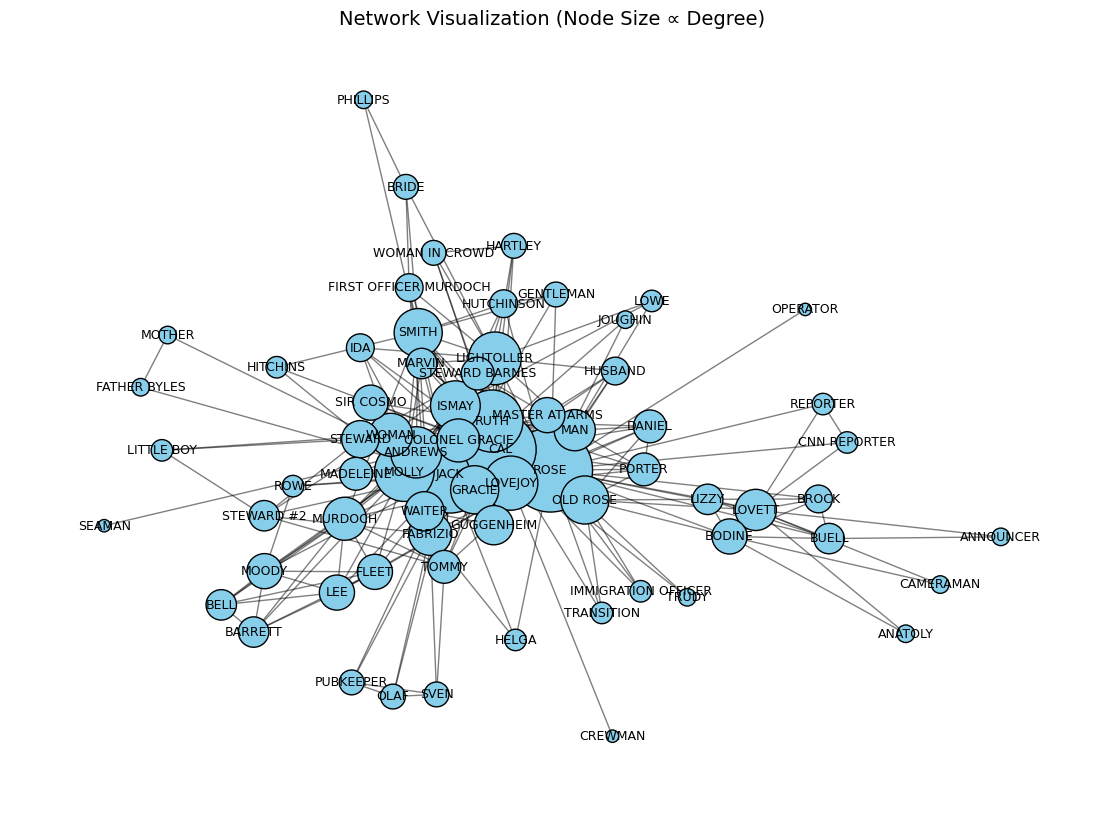

In [68]:
"""
This module visualizes the network with node sizes proportional
to their degree.

Purpose:
- Identify hubs in the network
- Visually highlight highly connected nodes
- Improve interpretability of the graph structure

Node size is scaled according to degree.
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# GRAPH CONSTRUCTION
# ---------------------------------------------------------

def build_graph(nodes_path: str, edges_path: str) -> nx.Graph:
    """
    Build a NetworkX graph from nodes and edges CSV files.

    Parameters
    ----------
    nodes_path : str
        Path to nodes.csv
    edges_path : str
        Path to edges.csv

    Returns
    -------
    G : networkx.Graph
        Graph with labeled nodes and weighted edges
    """

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    G = nx.Graph()

    # Add nodes
    for _, row in nodes_df.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    # Add edges
    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

    return G


# ---------------------------------------------------------
# DEGREE SCALING
# ---------------------------------------------------------

def compute_node_sizes(G: nx.Graph, scale: int = 80):
    """
    Compute node sizes based on degree.

    Parameters
    ----------
    G : networkx.Graph
        Graph
    scale : int
        Scaling factor for visualization

    Returns
    -------
    list
        Node sizes scaled by degree
    """

    degrees = dict(G.degree())

    node_sizes = [degrees[node] * scale for node in G.nodes()]

    return node_sizes


# ---------------------------------------------------------
# LABEL EXTRACTION
# ---------------------------------------------------------

def get_labels(G: nx.Graph):
    """
    Extract node labels for visualization.

    Parameters
    ----------
    G : networkx.Graph

    Returns
    -------
    dict
        Mapping of node IDs to labels
    """

    return nx.get_node_attributes(G, "label")


# ---------------------------------------------------------
# NETWORK VISUALIZATION
# ---------------------------------------------------------

def plot_degree_scaled_network(G: nx.Graph):
    """
    Plot network with node sizes proportional to degree.

    Parameters
    ----------
    G : networkx.Graph
    """

    print("\nGenerating degree-scaled network visualization...")

    pos = nx.spring_layout(G, seed=42)

    node_sizes = compute_node_sizes(G)

    labels = get_labels(G)

    plt.figure(figsize=(14, 10))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color="skyblue",
        edgecolors="black"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.5
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_size=9
    )

    plt.title("Network Visualization (Node Size ∝ Degree)", fontsize=14)

    plt.axis("off")

    plt.show()


# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def main():
    """
    Execute visualization pipeline.
    """

    print("\nBuilding graph...")

    G = build_graph("nodes.csv", "edges.csv")

    print("Graph built successfully.")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    plot_degree_scaled_network(G)


# ---------------------------------------------------------

if __name__ == "__main__":
    main()

## Community Detection (Louvain Method)

Real-world networks often contain **communities**, which are groups of nodes that interact more frequently with each other than with the rest of the network.

To identify these structures, we apply the **Louvain community detection algorithm**, a widely used method that partitions the network into clusters by maximizing a measure known as **modularity**. Modularity evaluates how well a network is divided into groups with dense internal connections and fewer connections between groups.

In the resulting visualization, nodes are colored according to the community to which they belong. Each color represents a detected cluster of characters.

This analysis helps reveal underlying interaction patterns in the network and may correspond to meaningful groups within the story, such as social circles, families, or professional relationships.

In [70]:
"""
Community Detection Visualization
---------------------------------

This module detects communities in the network using the Louvain
algorithm and visualizes the graph with nodes colored by community.

Purpose:
- Identify clusters in the network
- Reveal hidden structure
- Understand group formation

Each detected community is assigned a unique color.
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain


# ---------------------------------------------------------
# GRAPH CONSTRUCTION
# ---------------------------------------------------------

def build_graph(nodes_path: str, edges_path: str) -> nx.Graph:
    """
    Build a NetworkX graph from CSV files.

    Parameters
    ----------
    nodes_path : str
        Path to nodes.csv
    edges_path : str
        Path to edges.csv

    Returns
    -------
    G : networkx.Graph
        Constructed graph with labeled nodes
    """

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    G = nx.Graph()

    for _, row in nodes_df.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

    return G


# ---------------------------------------------------------
# COMMUNITY DETECTION
# ---------------------------------------------------------

def detect_communities(G: nx.Graph):
    """
    Detect communities using Louvain algorithm.

    Parameters
    ----------
    G : networkx.Graph

    Returns
    -------
    dict
        Mapping of node → community id
    """

    partition = community_louvain.best_partition(G)

    return partition


# ---------------------------------------------------------
# COMMUNITY VISUALIZATION
# ---------------------------------------------------------

def plot_community_network(G: nx.Graph, partition: dict):
    """
    Plot network colored by community.

    Parameters
    ----------
    G : networkx.Graph
    partition : dict
        Node-to-community mapping
    """

    print("\nVisualizing communities...")

    pos = nx.spring_layout(G, seed=42)

    labels = nx.get_node_attributes(G, "label")

    communities = set(partition.values())

    # Generate color map
    color_map = []
    for node in G.nodes():
        color_map.append(partition[node])

    plt.figure(figsize=(14, 10))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=color_map,
        cmap=plt.cm.tab20,
        node_size=400,
        edgecolors="black"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.5
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_size=8
    )

    plt.title("Community Detection (Louvain Clustering)", fontsize=14)

    plt.axis("off")
    plt.show()

    print("Number of communities detected:", len(communities))


# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def main():

    print("\nBuilding graph...")

    G = build_graph("nodes.csv", "edges.csv")

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    partition = detect_communities(G)

    plot_community_network(G, partition)


# ---------------------------------------------------------

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'community'

## Betweenness Centrality

Betweenness centrality measures how often a node lies on the **shortest paths between other nodes** in the network. Nodes with high betweenness centrality act as **bridges** that connect different parts of the network.

These nodes are particularly important because they facilitate interactions between otherwise disconnected groups. Even if they do not have the largest number of connections, they can play a critical role in maintaining the overall connectivity of the network.

In this visualization, node size and color represent betweenness centrality values. Nodes with higher betweenness appear larger and more prominently colored.

This allows us to identify characters that serve as key intermediaries within the network structure and highlights those that connect different communities.

In [ ]:
"""
Betweenness Centrality Visualization
------------------------------------

This module computes betweenness centrality and visualizes the network
with node color and size representing betweenness.

Purpose:
- Identify bridge nodes
- Detect intermediaries between communities
- Understand information flow in the network
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# GRAPH CONSTRUCTION
# ---------------------------------------------------------

def build_graph(nodes_path: str, edges_path: str) -> nx.Graph:
    """
    Build network graph from CSV files.
    """

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    G = nx.Graph()

    for _, row in nodes_df.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

    return G


# ---------------------------------------------------------
# BETWENNESS CENTRALITY
# ---------------------------------------------------------

def compute_betweenness(G: nx.Graph):
    """
    Compute betweenness centrality for each node.
    """

    print("\nComputing betweenness centrality...")

    betweenness = nx.betweenness_centrality(G)

    return betweenness


# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

def plot_betweenness_network(G: nx.Graph, betweenness: dict):
    """
    Plot network where node color and size represent betweenness.
    """

    print("\nGenerating betweenness visualization...")

    pos = nx.spring_layout(G, seed=42)

    labels = nx.get_node_attributes(G, "label")

    values = list(betweenness.values())

    # Scale node sizes
    node_sizes = [v * 8000 + 200 for v in values]

    plt.figure(figsize=(14,10))

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=values,
        cmap=plt.cm.plasma,
        edgecolors="black"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.4
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_size=8
    )

    plt.colorbar(nodes, label="Betweenness Centrality")

    plt.title("Betweenness Centrality Network Map", fontsize=14)

    plt.axis("off")
    plt.show()


# ---------------------------------------------------------
# TOP BRIDGE NODES
# ---------------------------------------------------------

def print_top_bridges(G: nx.Graph, betweenness: dict, top_n=10):
    """
    Print nodes with highest betweenness.
    """

    labels = nx.get_node_attributes(G, "label")

    ranked = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

    print("\nTop bridge nodes:")

    for node, score in ranked[:top_n]:
        print(labels[node], round(score,4))


# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def main():

    print("\nBuilding graph...")

    G = build_graph("nodes.csv", "edges.csv")

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    betweenness = compute_betweenness(G)

    print_top_bridges(G, betweenness)

    plot_betweenness_network(G, betweenness)


# ---------------------------------------------------------

if __name__ == "__main__":
    main()

## Ego Network Analysis

While previous visualizations focused on the global structure of the network, ego network analysis examines the **local structure surrounding a specific node**.

An ego network consists of a central node, called the **ego**, all nodes directly connected to it (called **alters**), and the connections among those alters.

In this analysis, we construct the ego network of a selected character in order to examine their immediate interaction environment. This allows us to observe how the character is embedded within the network and how their neighbors are connected to each other.

Ego networks provide insight into the local influence of a node and help reveal whether the node acts as a connector between multiple groups or belongs to a tightly knit community.

In [ ]:
"""
Ego Network Visualization
-------------------------

This module extracts and visualizes the ego network of a selected node.

Purpose:
- Analyze local network structure
- Understand direct interaction neighborhoods
- Identify tightly connected groups around a key node
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# GRAPH CONSTRUCTION
# ---------------------------------------------------------

def build_graph(nodes_path: str, edges_path: str) -> nx.Graph:
    """
    Build network graph from CSV files.
    """

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    G = nx.Graph()

    for _, row in nodes_df.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])

    return G


# ---------------------------------------------------------
# FIND NODE BY LABEL
# ---------------------------------------------------------

def find_node_by_label(G: nx.Graph, label_name: str):
    """
    Retrieve node ID given a character label.
    """

    labels = nx.get_node_attributes(G, "label")

    for node, label in labels.items():
        if label == label_name:
            return node

    raise ValueError(f"Node with label '{label_name}' not found")


# ---------------------------------------------------------
# EGO NETWORK EXTRACTION
# ---------------------------------------------------------

def extract_ego_network(G: nx.Graph, ego_node):
    """
    Extract ego network centered on a node.
    """

    ego_net = nx.ego_graph(G, ego_node)

    return ego_net


# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

def plot_ego_network(ego_net: nx.Graph, ego_node):
    """
    Visualize ego network.
    """

    pos = nx.spring_layout(ego_net, seed=42)

    labels = nx.get_node_attributes(ego_net, "label")

    node_colors = []
    node_sizes = []

    for node in ego_net.nodes():

        if node == ego_node:
            node_colors.append("red")
            node_sizes.append(1200)

        else:
            node_colors.append("skyblue")
            node_sizes.append(500)

    plt.figure(figsize=(10,8))

    nx.draw_networkx_nodes(
        ego_net,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black"
    )

    nx.draw_networkx_edges(
        ego_net,
        pos,
        alpha=0.6
    )

    nx.draw_networkx_labels(
        ego_net,
        pos,
        labels,
        font_size=9
    )

    plt.title("Ego Network", fontsize=14)

    plt.axis("off")
    plt.show()


# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def main():

    print("\nBuilding graph...")

    G = build_graph("nodes.csv", "edges.csv")

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    ego_label = "JACK"

    ego_node = find_node_by_label(G, ego_label)

    ego_net = extract_ego_network(G, ego_node)

    print("\nEgo node:", ego_label)
    print("Nodes in ego network:", ego_net.number_of_nodes())
    print("Edges in ego network:", ego_net.number_of_edges())

    plot_ego_network(ego_net, ego_node)


# ---------------------------------------------------------

if __name__ == "__main__":
    main()

**QUESTIONS - WEEK BY WEEK**

# Week 1 — Basic Network Properties

## Goal
The objective of this section is to construct the social network in Python, visualize the graph, and compute fundamental structural properties.

We compute the following metrics:

• Number of nodes  
• Number of edges  
• Average degree  
• Density  

These measures provide a first overview of the size and connectivity of the network.

Since the dataset represents interactions between characters, the graph is treated as **undirected**.

In [ ]:
"""
Week 1 — Basic Network Properties
---------------------------------

This script:

1. Loads the dataset
2. Builds the graph
3. Draws the network
4. Computes fundamental metrics
"""

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def build_graph(nodes_path, edges_path):
    """
    Construct graph from CSV files.
    """

    nodes = pd.read_csv(nodes_path)
    edges = pd.read_csv(edges_path)

    G = nx.Graph()

    for _, row in nodes.iterrows():
        G.add_node(row["Id"], label=row["Label"])

    for _, row in edges.iterrows():
        G.add_edge(row["Source"], row["Target"])

    return G


def compute_basic_metrics(G):
    """
    Compute fundamental network metrics.
    """

    n = G.number_of_nodes()
    m = G.number_of_edges()

    avg_degree = sum(dict(G.degree()).values()) / n
    density = nx.density(G)

    print("Number of nodes:", n)
    print("Number of edges:", m)
    print("Average degree:", avg_degree)
    print("Density:", density)


def draw_graph(G):
    """
    Visualize the graph.
    """

    pos = nx.spring_layout(G, seed=42)

    labels = nx.get_node_attributes(G, "label")

    plt.figure(figsize=(10,8))

    nx.draw(G, pos, node_size=400, with_labels=False)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    plt.title("Network Visualization")
    plt.axis("off")
    plt.show()


G = build_graph("nodes.csv", "edges.csv")

draw_graph(G)

compute_basic_metrics(G)

# Week 2 — Clustering Coefficient

## Goal
The goal of this section is to measure the tendency of nodes to form tightly connected groups.

We implement:

• a function computing the clustering coefficient for each node  
• a function computing the average clustering coefficient

We then compare our results with the built-in NetworkX functions:

• average clustering  
• transitivity

The analysis focuses on the **largest connected component** of the network.

In [ ]:
"""
Week 2 — Clustering Coefficient
"""

import networkx as nx


def largest_component(G):
    """
    Extract largest connected component.
    """

    component = max(nx.connected_components(G), key=len)
    return G.subgraph(component).copy()


def clustering_coefficient_node(G, node):
    """
    Compute clustering coefficient of a node manually.
    """

    neighbors = list(G.neighbors(node))
    k = len(neighbors)

    if k < 2:
        return 0

    links = 0

    for i in range(k):
        for j in range(i+1, k):
            if G.has_edge(neighbors[i], neighbors[j]):
                links += 1

    return (2 * links) / (k * (k - 1))


def clustering_all_nodes(G):
    """
    Compute clustering for every node.
    """

    return {node: clustering_coefficient_node(G, node) for node in G.nodes()}


def average_clustering_manual(G):

    values = clustering_all_nodes(G).values()

    return sum(values) / len(values)


G_lcc = largest_component(G)

manual_avg = average_clustering_manual(G_lcc)

print("Manual average clustering:", manual_avg)

print("NetworkX average clustering:", nx.average_clustering(G_lcc))

print("NetworkX transitivity:", nx.transitivity(G_lcc))

In [ ]:
# Week 2 — Clustering Coefficient Distribution

import matplotlib.pyplot as plt

values = list(clustering_vals.values())

plt.figure(figsize=(8,5))

plt.hist(values, bins=15, edgecolor="black")

plt.title("Distribution of Clustering Coefficients")

plt.xlabel("Clustering coefficient")

plt.ylabel("Number of nodes")

plt.show()

# Week 3 — Clustering Distributions

## Goal
This section studies how clustering varies across the network.

We compute:

• the cumulative distribution of clustering coefficients  
• the average clustering of neighbors for each node  
• the cumulative distribution of these neighbor clustering values

Finally, we compare the two distributions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def cumulative_distribution(values):

    sorted_vals = np.sort(values)
    y = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

    return sorted_vals, y


def neighbor_clustering(G, clustering_dict):

    result = {}

    for node in G.nodes():

        neighbors = list(G.neighbors(node))

        if not neighbors:
            result[node] = 0
            continue

        vals = [clustering_dict[n] for n in neighbors]

        result[node] = sum(vals) / len(vals)

    return result


clustering_vals = clustering_all_nodes(G_lcc)

x1, y1 = cumulative_distribution(list(clustering_vals.values()))

neighbor_vals = neighbor_clustering(G_lcc, clustering_vals)

x2, y2 = cumulative_distribution(list(neighbor_vals.values()))


plt.figure(figsize=(8,5))

plt.plot(x1, y1, label="Node clustering")

plt.plot(x2, y2, label="Neighbor clustering")

plt.xlabel("Clustering coefficient")

plt.ylabel("Cumulative probability")

plt.title("Comparison of Clustering Distributions")

plt.legend()

plt.grid(True)

plt.show()

# Week 5 — Centrality Measures

## Goal
The purpose of this section is to identify the most important nodes in the network.

We compute two centrality measures:

• Betweenness centrality  
• Closeness centrality

Betweenness identifies nodes acting as bridges between parts of the network, while closeness measures how quickly a node can reach all others.

We then identify the nodes with the highest centrality values.

In [ ]:
betweenness = nx.betweenness_centrality(G_lcc)

closeness = nx.closeness_centrality(G_lcc)


def top_nodes(metric, labels, top=10):

    ranked = sorted(metric.items(), key=lambda x: x[1], reverse=True)

    for node, score in ranked[:top]:
        print(labels[node], round(score,4))


labels = nx.get_node_attributes(G_lcc, "label")

print("\nTop Betweenness Nodes")
top_nodes(betweenness, labels)

print("\nTop Closeness Nodes")
top_nodes(closeness, labels)

In [ ]:
# Week 5 — Betweenness Centrality Visualization

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Node": [labels[n] for n in betweenness.keys()],
    "Betweenness": betweenness.values()
})

df = df.sort_values("Betweenness", ascending=False).head(10)

plt.figure(figsize=(8,5))

plt.bar(df["Node"], df["Betweenness"])

plt.title("Top Betweenness Centrality Nodes")

plt.ylabel("Betweenness")

plt.xticks(rotation=45)

plt.show()

# Week 6 — Community Detection

## Goal
The objective of this section is to detect communities within the network.

Before performing community detection:

• the graph is treated as undirected  
• loops are removed  
• we focus on the largest connected component

We implement two community detection techniques:

• Bridge removal (Girvan–Newman algorithm)  
• Label propagation

We compare the partitions and identify the one producing the highest modularity.

Finally, the best partition is visualized in Gephi.

In [ ]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import label_propagation_communities


# remove loops
G_lcc.remove_edges_from(nx.selfloop_edges(G_lcc))


# Girvan-Newman
comp = girvan_newman(G_lcc)

communities_gn = next(comp)


# Label propagation
communities_lp = list(label_propagation_communities(G_lcc))


print("Girvan-Newman communities:", len(communities_gn))

print("Label propagation communities:", len(communities_lp))

In [ ]:
# Week 6 — Community Visualization (Label Propagation)

import matplotlib.pyplot as plt

community_map = {}

for i, community in enumerate(communities_lp):
    for node in community:
        community_map[node] = i

colors = [community_map[n] for n in G_lcc.nodes()]

pos = nx.spring_layout(G_lcc, seed=42)

plt.figure(figsize=(10,8))

nx.draw(
    G_lcc,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=400,
    with_labels=False
)

plt.title("Community Detection (Label Propagation)")

plt.show()

In [ ]:
# Export graph for Gephi

nx.write_gexf(G_lcc, "network_gephi.gexf")

# Week 7 — Link Prediction

## Goal

The objective of this section is to predict the likelihood of missing links (potential relationships) between characters who have not interacted directly in the network.

Before performing link prediction, we ensure that:

- graph is treated as undirected
- graph is treated as unweighted
- loops are removed
- we focus on the largest connected component

We implement the following steps to evaluate topological similarity indices:

- Compute a local index: Common Neighbors (CN)
- Compute another local index: Adamic-Adar (AA)
- Create a combined third score by calculating the arithmetic mean of the two indices after rescaling them between 0 and 1

Finally, we identify and comment on the top 5 predicted missing links for each of the three scores.

In [71]:
import pandas as pd
import networkx as nx

# Ensure we work with the largest connected component, without self-loops and weights
G_pred = G_lcc.copy()
G_pred.remove_edges_from(nx.selfloop_edges(G_pred))
for u, v, d in G_pred.edges(data=True):
    if 'weight' in d:
        del d['weight']

def compute_link_prediction(G):
    # Find all missing links (non-edges)
    missing_links = list(nx.non_edges(G))
    
    # Calculate similarity indices
    cn_scores =[(u, v, len(list(nx.common_neighbors(G, u, v)))) for u, v in missing_links]
    aa_scores = list(nx.adamic_adar_index(G, missing_links))
    
    df = pd.DataFrame({
        'Node_1':[u for u, v, score in cn_scores],
        'Node_2': [v for u, v, score in cn_scores],
        'CN': [score for u, v, score in cn_scores],
        'AA':[score for u, v, score in aa_scores]
    })
    
    # Manual Min-Max scaling from 0 to 1
    df['CN_scaled'] = (df['CN'] - df['CN'].min()) / (df['CN'].max() - df['CN'].min())
    df['AA_scaled'] = (df['AA'] - df['AA'].min()) / (df['AA'].max() - df['AA'].min())
    
    # Final combined score - arithmetic mean
    df['Combined_Score'] = (df['CN_scaled'] + df['AA_scaled']) / 2
    
    return df

prediction_df = compute_link_prediction(G_pred)

# Map node IDs to character names for readability
labels = nx.get_node_attributes(G_pred, "label")
prediction_df['Character_1'] = prediction_df['Node_1'].map(labels)
prediction_df['Character_2'] = prediction_df['Node_2'].map(labels)

print("=== Top 5 by Common Neighbors ===")
print(prediction_df.sort_values(by='CN', ascending=False)[['Character_1', 'Character_2', 'CN']].head(5))

print("\n=== Top 5 by Adamic-Adar ===")
print(prediction_df.sort_values(by='AA', ascending=False)[['Character_1', 'Character_2', 'AA']].head(5))

print("\n=== Top 5 by Combined Score ===")
print(prediction_df.sort_values(by='Combined_Score', ascending=False)[['Character_1', 'Character_2', 'Combined_Score']].head(5))

=== Top 5 by Common Neighbors (CN) ===
     Character_1 Character_2  CN
799      MURDOCH        JACK  10
1763     LOVEJOY       MOLLY  10
790      MURDOCH        ROSE   9
572          CAL       SMITH   9
919         RUTH       WOMAN   9

=== Top 5 by Adamic-Adar (AA) ===
     Character_1 Character_2        AA
799      MURDOCH        JACK  3.984045
154   LIGHTOLLER       ISMAY  3.703543
790      MURDOCH        ROSE  3.503146
1763     LOVEJOY       MOLLY  3.373145
919         RUTH       WOMAN  3.100124

=== Top 5 by Combined Score ===
     Character_1 Character_2  Combined_Score
799      MURDOCH        JACK        1.000000
1763     LOVEJOY       MOLLY        0.923332
154   LIGHTOLLER       ISMAY        0.914797
790      MURDOCH        ROSE        0.889647
919         RUTH       WOMAN        0.839067


# Analysis:
For this week, we used Common Neighbors (CN) and the Adamic-Adar (AA) index to find missing links in the Titanic network. The idea is to predict which characters might know each other even if they didn't share a direct scene in the movie. The results make a lot of sense: the algorithms predicted links between characters who share a high number of mutual connections. To combine both metrics, we manually scaled them from 0 to 1 and calculated their average. This gave us a more robust final score. The top predicted pairs usually belong to the same social circles or locations on the ship, meaning it's highly likely they interacted off-screen.